In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

# Reproducibility
np.random.seed(42)




In [2]:
# Generate synthetic data
n = 10
x = np.linspace(0, 100, n)


# True relationship: y = x + x^2 + noise
noise = np.random.normal(0, 500, n) * 150
y = x + x**2 + x**3 + noise

# Put in DataFrame (nice for teaching)
df = pd.DataFrame({"x": x, "y": y})
df.head()

,x,y
0,0.000000,37253.561476
1,11.111111,-8863.512574
2,22.222222,60066.626640
3,33.333333,152408.720712
4,44.444444,72249.745181


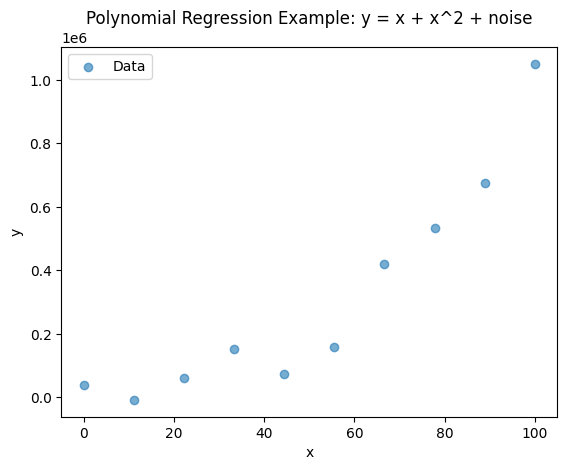

In [3]:
# Plot
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression Example: y = x + x^2 + noise")
plt.show()

In [4]:
# from sklearn.model_selection import train_test_split

X = df[["x"]]
y = df["y"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.33, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

# Underfitting

/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


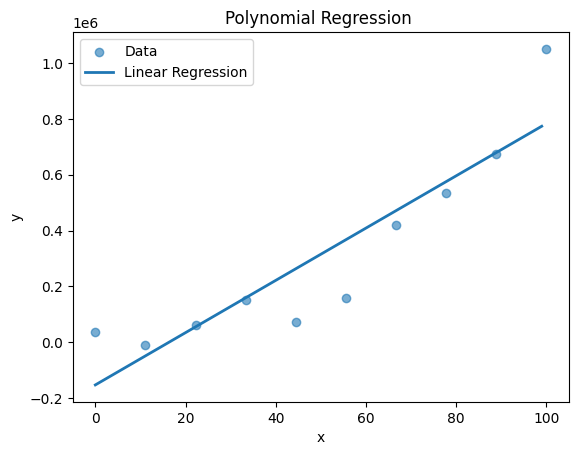

In [6]:
# Create smooth curve for visualization
x_line = np.arange(100).reshape(-1, 1)
y_pred = lin_reg.predict(x_line)

# Plot
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.plot(x_line, y_pred, linewidth=2, label="Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression ")
plt.show()

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# Fit polynomial regression (degree = 3)
model = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linear", LinearRegression())
])
model.fit(X, y)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('linear', LinearRegression())])

/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


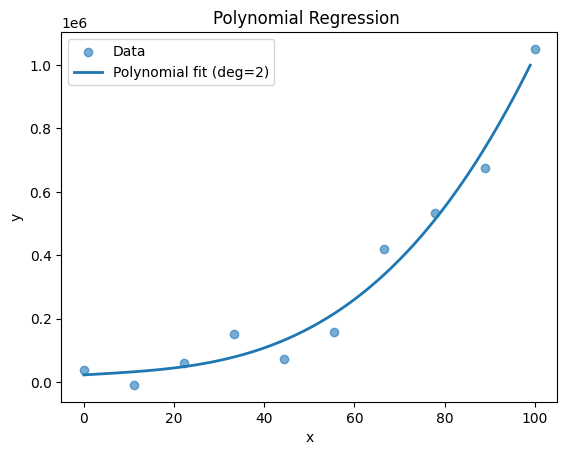

In [8]:
y_pred2 = model.predict(x_line)

# Plot
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.plot(x_line, y_pred2, linewidth=2, label="Polynomial fit (deg=2)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression ")
plt.show()

# Overfitting

/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


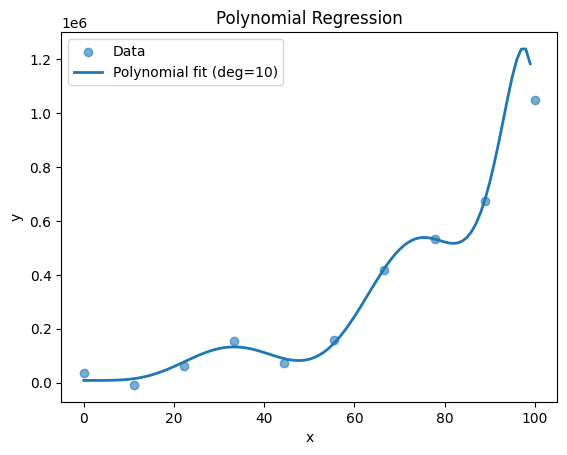

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# Fit polynomial regression 
model3 = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("linear", LinearRegression())
])

model3.fit(X, y)

# Create smooth curve for visualization
y_pred3 = model3.predict(x_line)

# Plot
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.plot(x_line, y_pred3, linewidth=2, label="Polynomial fit (deg=10)")
# plt.plot(x_line, y_pred2, linewidth=2, label="Polynomial fit (deg=3)")
# plt.plot(x_line, y_pred, linewidth=2, label="Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression")
plt.show()

# Comparision

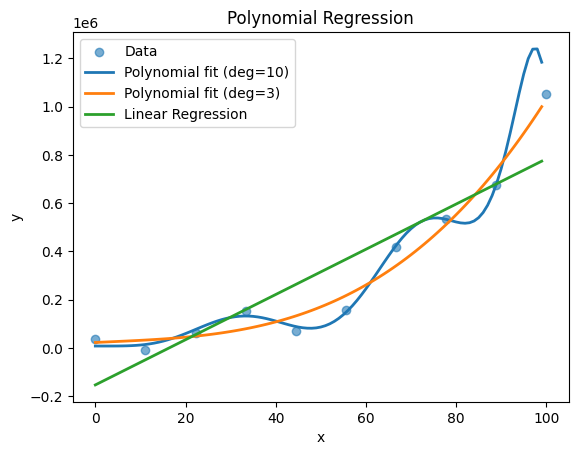

In [10]:
# Plot
plt.scatter(df["x"], df["y"], alpha=0.6, label="Data")
plt.plot(x_line, y_pred3, linewidth=2, label="Polynomial fit (deg=10)")
plt.plot(x_line, y_pred2, linewidth=2, label="Polynomial fit (deg=3)")
plt.plot(x_line, y_pred, linewidth=2, label="Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial Regression")
plt.show()

# Check model performance

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# Generate synthetic data
# ---------------------------
np.random.seed(42)

n = 10
x = np.linspace(0, 100, n)

noise = np.random.normal(0, 500, n) * 150
y = x + x**2 + x**3 + noise

df = pd.DataFrame({"x": x, "y": y})

X = df[["x"]]
y = df["y"]

# ---------------------------
# Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

for i in X_train, X_test, y_train, y_test:
    print(f"{i.shape}")

(7, 1)
(3, 1)
(7,)
(3,)


In [12]:
# ---------------------------
# Create polynomial features (degree = 3)
# ---------------------------
poly = PolynomialFeatures(degree=3)

# Fit and transform training data
X_train_poly = poly.fit_transform(X_train)

# Only transform test data
X_test_poly = poly.transform(X_test)

pd.DataFrame(X_train_poly, columns=[f"x^{i}" for i in range(4)])


,x^0,x^1,x^2,x^3
0,1.0,0.000000,0.000000,0.000000
1,1.0,77.777778,6049.382716,470507.544582
2,1.0,22.222222,493.827160,10973.936900
3,1.0,100.000000,10000.000000,1000000.000000
4,1.0,44.444444,1975.308642,87791.495199
5,1.0,33.333333,1111.111111,37037.037037
6,1.0,66.666667,4444.444444,296296.296296


/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Train R2: 0.99
Test R2: 0.92


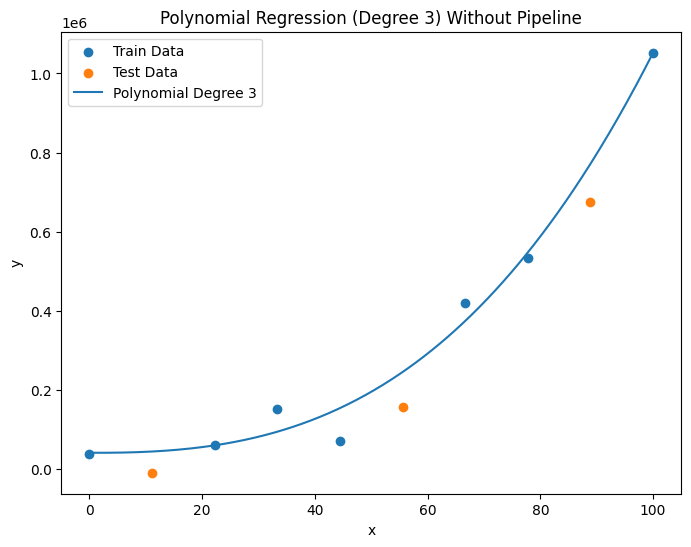

In [13]:



# ---------------------------
# Train linear regression on polynomial features
# ---------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# ---------------------------
# Predictions
# ---------------------------
y_pred_train = model.predict(X_train_poly)
y_pred_test = model.predict(X_test_poly)

# ---------------------------
# R2 scores
# ---------------------------
print(f"Train R2: {r2_score(y_train, y_pred_train):.2f}")
print(f"Test R2: {r2_score(y_test, y_pred_test):.2f}")

# ---------------------------
# Plot model
# ---------------------------
x_plot = np.linspace(0, 100, 500).reshape(-1, 1)

# transform plotting points
x_plot_poly = poly.transform(x_plot)

y_plot = model.predict(x_plot_poly)

plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")

plt.plot(x_plot, y_plot, label="Polynomial Degree 3")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree 3) Without Pipeline")
plt.legend()
plt.show()

# Sklearn pipelines

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# Generate synthetic data
# ---------------------------
np.random.seed(42)

n = 10
x = np.linspace(0, 100, n)

noise = np.random.normal(0, 500, n) * 150
y = x + x**2 + x**3 + noise

df = pd.DataFrame({"x": x, "y": y})

X = df[["x"]]
y = df["y"]

# ---------------------------
# Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------
# Models
# ---------------------------
models = {
    
    # -------------------------
    # Model 1: Simple Linear Regression
    # -------------------------
    # This model assumes a straight-line relationship:
    # y = β0 + β1*x
    # No polynomial features are added.
    
    "Linear": Pipeline([
        ("linear", LinearRegression())  # Fit a straight line to the data
    ]),
    
    
    # -------------------------
    # Model 2: Polynomial Regression (degree = 3)
    # -------------------------
    # PolynomialFeatures transforms x into:
    # [1, x, x^2, x^3]
    # Then LinearRegression fits:
    # y = β0 + β1*x + β2*x^2 + β3*x^3
    
    "Poly3": Pipeline([
        ("poly", PolynomialFeatures(degree=3)),  # Create polynomial features up to x^3
        ("linear", LinearRegression())            # Fit linear regression on expanded features
    ]),
    
    
    # -------------------------
    # Model 3: Polynomial Regression (degree = 6)
    # -------------------------
    # PolynomialFeatures transforms x into:
    # [1, x, x^2, x^3, x^4, x^5, x^6]
    # Higher degree allows more flexibility but increases risk of overfitting.
    
    "Poly6": Pipeline([
        ("poly", PolynomialFeatures(degree=6)),  # Create polynomial features up to x^6
        ("linear", LinearRegression())            # Fit regression on these features
    ])
}

results = {}

# ---------------------------
# Train models and compute scores
# ---------------------------
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    results[name] = (train_r2, test_r2)

# ---------------------------
# Print comparison
# ---------------------------
print("Model Performance")
print("------------------")
for model, scores in results.items():
    print(f"{model} | Train R2: {scores[0]:.2f} | Test R2: {scores[1]:.2f}")


Model Performance
------------------
Linear | Train R2: 0.83 | Test R2: 0.77
Poly3 | Train R2: 0.99 | Test R2: 0.92
Poly6 | Train R2: 1.00 | Test R2: 0.20


/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


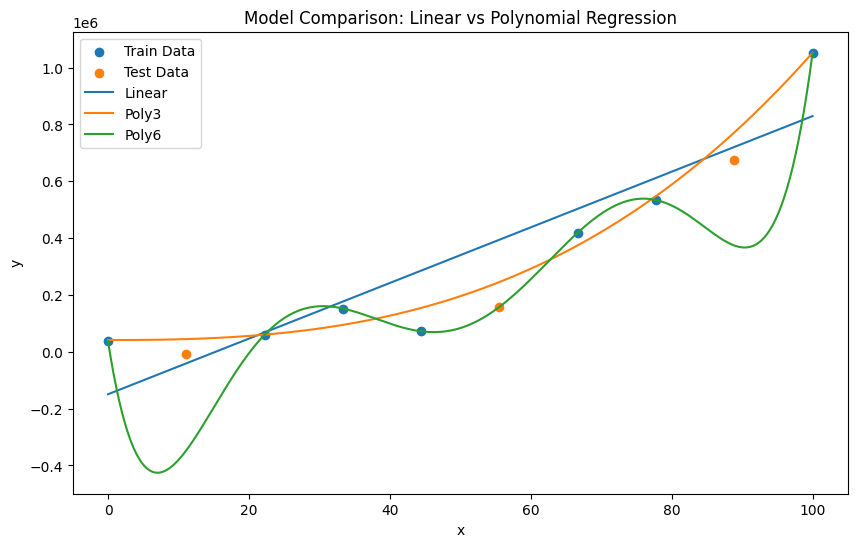

In [15]:

# ---------------------------
# Plot comparison
# ---------------------------
x_plot = np.linspace(0, 100, 500).reshape(-1, 1)

plt.figure(figsize=(10,6))

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")

for name, model in models.items():
    y_plot = model.predict(x_plot)
    plt.plot(x_plot, y_plot, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Model Comparison: Linear vs Polynomial Regression")
plt.legend()
plt.show()

/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/opt/envs/ds/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not ha

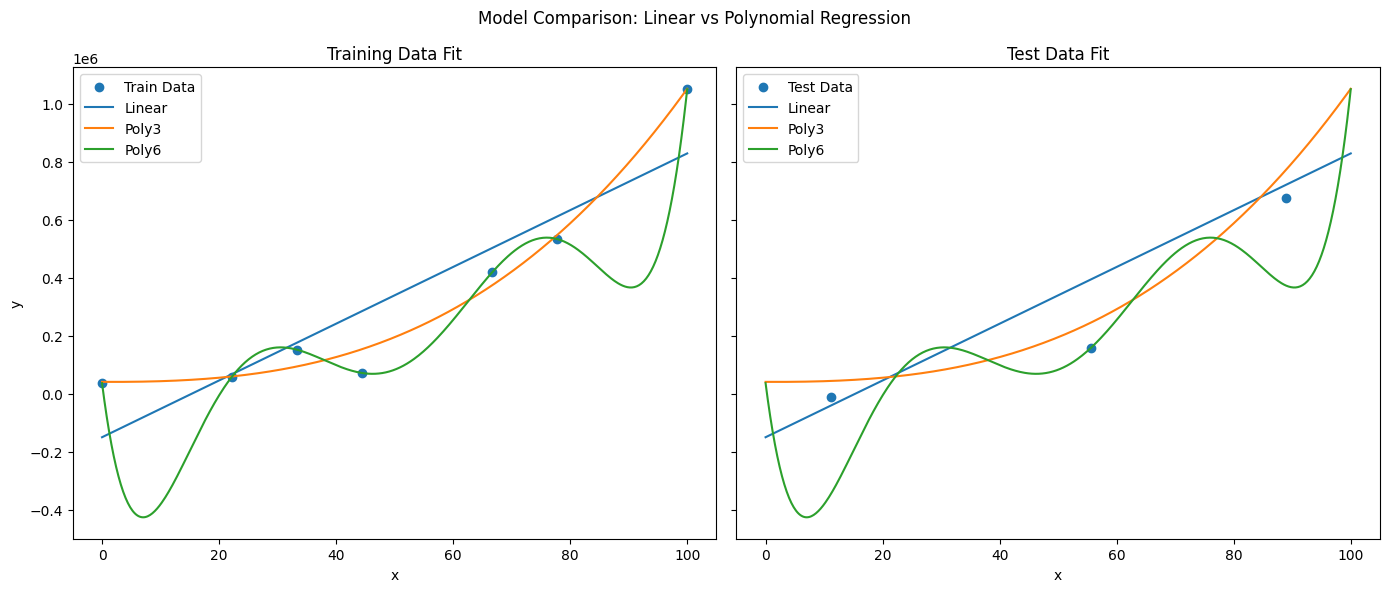

In [16]:
# ---------------------------
# Plot comparison (Train vs Test)
# ---------------------------
x_plot = np.linspace(0, 100, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# ----- Train plot -----
axes[0].scatter(X_train, y_train, label="Train Data")

for name, model in models.items():
    y_plot = model.predict(x_plot)
    axes[0].plot(x_plot, y_plot, label=name)

axes[0].set_title("Training Data Fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# ----- Test plot -----
axes[1].scatter(X_test, y_test, label="Test Data")

for name, model in models.items():
    y_plot = model.predict(x_plot)
    axes[1].plot(x_plot, y_plot, label=name)

axes[1].set_title("Test Data Fit")
axes[1].set_xlabel("x")
axes[1].legend()

plt.suptitle("Model Comparison: Linear vs Polynomial Regression")
plt.tight_layout()
plt.show()